In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import os 

BASE_PATH = "../data/processed"
df_model = pd.read_csv(os.path.join(BASE_PATH, "df_model.csv"))

## **ANALISIS GENERAL** ##

In [5]:
# Análisis de distribución de productos por categoría
categorias_productos = (
    df_model.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["product_id"]
    .nunique()
    .reset_index(name="numero_productos")
    .sort_values(by="numero_productos", ascending=False)
)

categorias_productos.head(20)

,product_category_name_english,numero_productos
7,bed_bath_table,3029
65,sports_leisure,2867
39,furniture_decor,2657
43,health_beauty,2444
49,housewares,2335
5,auto,1900
15,computers_accessories,1639
69,toys,1411
70,watches_gifts,1329
68,telephony,1134


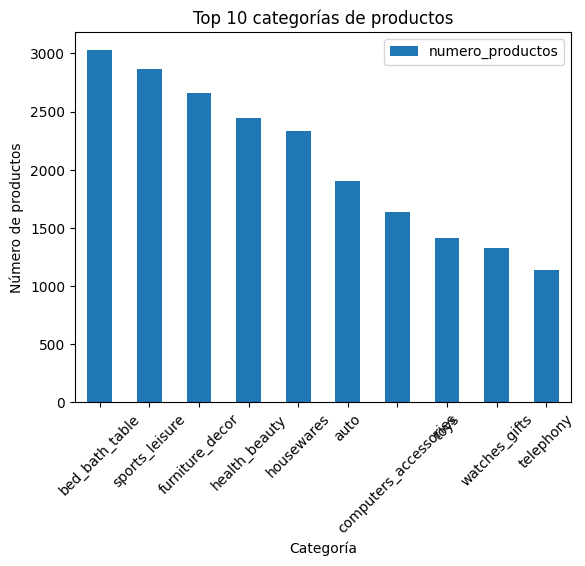

In [6]:
# Gráfica de distribución de productos por categoría
categorias_productos.head(10).plot(
    x="product_category_name_english",
    y="numero_productos",
    kind="bar"
)

plt.title("Top 10 categorías de productos")
plt.ylabel("Número de productos")
plt.xlabel("Categoría")
plt.xticks(rotation=45)
plt.show()

El análisis de la distribución de productos por categoría evidencia que la oferta del e-commerce se concentra principalmente en categorías relacionadas con el hogar y el estilo de vida.

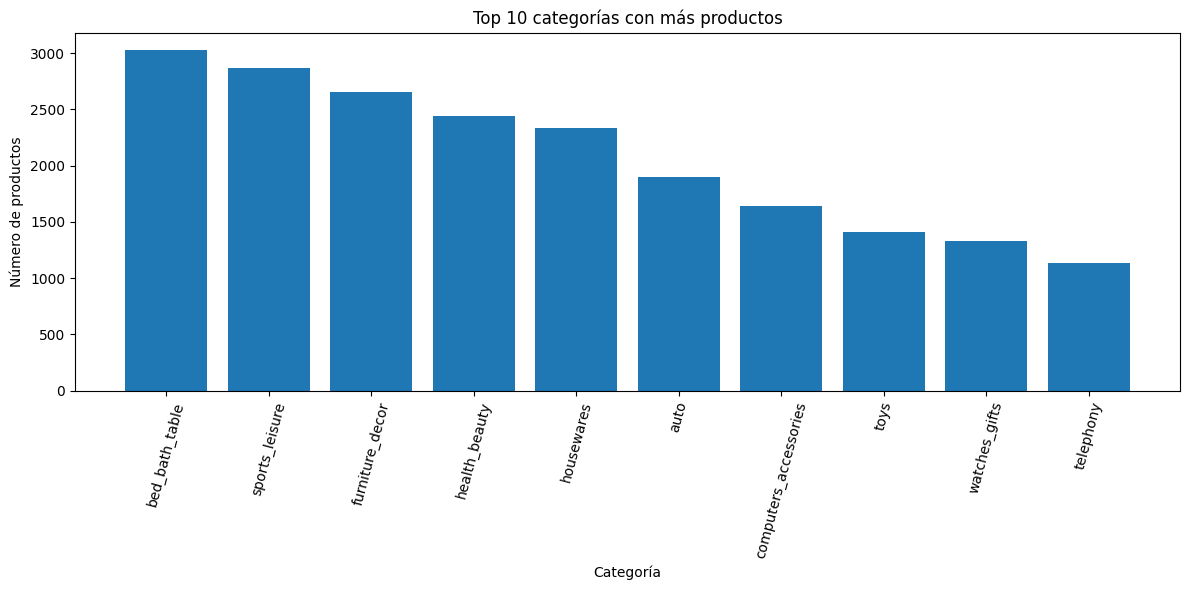

In [7]:
# categorías con mayor número de productos
top_10_categorias = categorias_productos.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_10_categorias["product_category_name_english"], top_10_categorias["numero_productos"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías con más productos")
plt.xlabel("Categoría")
plt.ylabel("Número de productos")
plt.tight_layout()
plt.show()

El gráfico de las 10 categorías con mayor número de productos muestra que la oferta del marketplace se concentra principalmente en categorías relacionadas con el hogar, el bienestar y el estilo de vida.

La categoría bed_bath_table registra la mayor cantidad de productos, seguida de sports_leisure y furniture_decor. Esto sugiere que el catálogo tiene una fuerte orientación hacia artículos de uso doméstico, decoración y recreación.

También se evidencia la presencia de categorías tecnológicas y de consumo personal, como computers_accessories, telephony y watches_gifts, aunque con una participación menor dentro del total de productos.

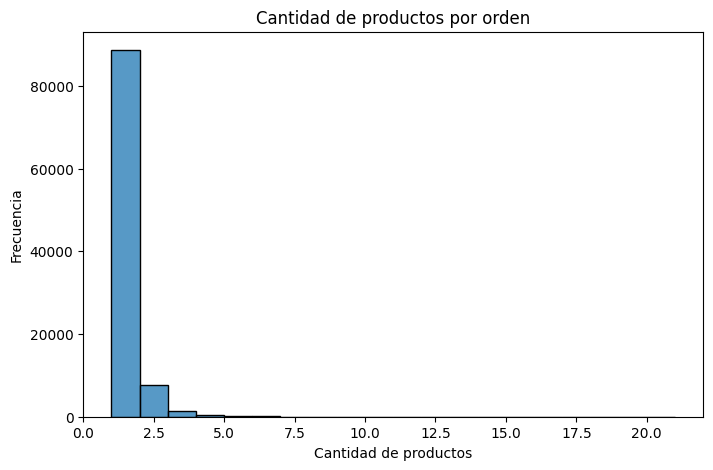

In [8]:
# histograma de cantidad de productos por pedido
productos_por_orden = df_model.groupby("order_id")["order_item_id"].count()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(productos_por_orden, bins=20)
plt.title("Cantidad de productos por orden")
plt.xlabel("Cantidad de productos")
plt.ylabel("Frecuencia")
plt.show()

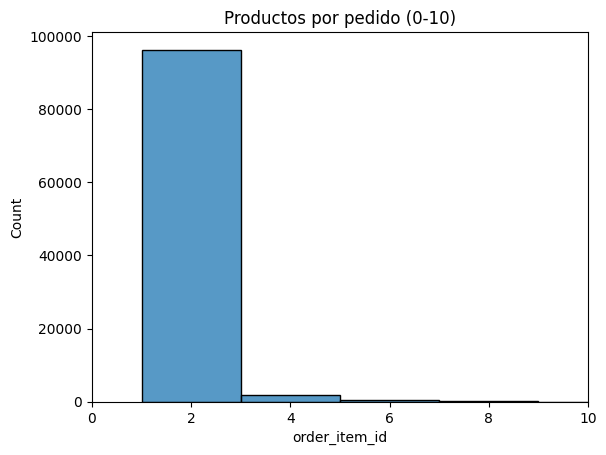

In [9]:
# # histograma de cantidad de productos por pedido
sns.histplot(productos_por_orden, bins=10)
plt.xlim(0,10)
plt.title("Productos por pedido (0-10)")
plt.show()

Los clientes compran principalmente un solo producto por pedido

La distribución de la cantidad de productos por pedido muestra que la mayoría de las órdenes contienen un solo producto, lo que indica un comportamiento de compra simple y directo por parte de los clientes.

Un menor porcentaje de pedidos incluye dos o más productos, mientras que los pedidos con una alta cantidad de artículos son poco frecuentes.

In [10]:
# Ingresos totales por categoría
ventas_categoria = (
    df_model
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["price"]
    .sum()
    .reset_index(name="ingresos_totales")
    .sort_values(by="ingresos_totales", ascending=False)
)

ventas_categoria.head(10)

,product_category_name_english,ingresos_totales
43,health_beauty,1259596.19
70,watches_gifts,1205895.34
7,bed_bath_table,1042324.22
65,sports_leisure,989255.25
15,computers_accessories,915860.55
39,furniture_decor,733539.22
20,cool_stuff,636019.54
49,housewares,632547.53
5,auto,592918.45
42,garden_tools,485650.75


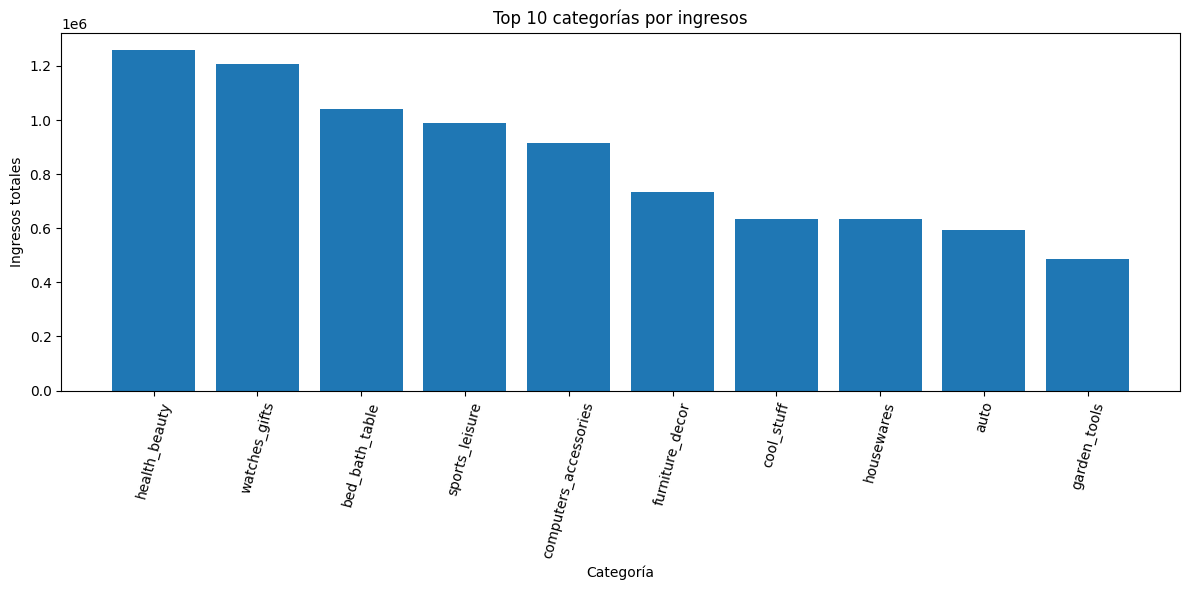

In [11]:
# Gráfica Ingresos totales por categoría
top_ventas = ventas_categoria.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_ventas["product_category_name_english"], top_ventas["ingresos_totales"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías por ingresos")
plt.ylabel("Ingresos totales")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

El análisis de ingresos por categoría evidencia que las categorías más rentables no coinciden completamente con aquellas que tienen mayor número de productos.

La categoría health_beauty lidera en generación de ingresos, seguida de watches_gifts y bed_bath_table, lo que indica una alta demanda o mayor valor promedio por producto en estos segmentos.

Asimismo, categorías como computers_accessories muestran un alto nivel de ingresos a pesar de no estar entre las más numerosas, lo que sugiere precios unitarios más elevados o mayor rotación de productos.

In [12]:
#tabla analítica  cruza ventas con categorías
items_con_categoria = df_model[
    ["order_id", "product_id", "product_category_name_english", "grupo_categoria", "price"]
]

items_con_categoria.head()

,order_id,product_id,product_category_name_english,grupo_categoria,price
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,Recreación,58.90
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,Recreación,239.90
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,Hogar,199.00
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumery,Cuidado Personal,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,garden_tools,other,199.90


Se realizó la integración de la tabla de ítems de pedidos (order_items) con la información de productos (products), con el fin de incorporar la categoría de cada producto a las transacciones.

Esta unión se realizó mediante la variable product_id, utilizando un left join para conservar la totalidad de los registros de ventas.

Como resultado, se obtuvo una tabla enriquecida que permite analizar el comportamiento de ventas por categoría, incluyendo variables como precio y costo de envío.

In [13]:
# Ticket promedio por categoría
ticket_promedio = (
    items_con_categoria
    .groupby("product_category_name_english")["price"]
    .mean()
    .reset_index(name="precio_promedio")
    .sort_values(by="precio_promedio", ascending=False)
)

ticket_promedio.head(10)

,product_category_name_english,precio_promedio
14,computers,1098.340542
64,small_appliances_home_oven_and_coffee,624.285658
45,home_appliances_2,476.124958
0,agro_industry_and_commerce,342.124858
56,musical_instruments,281.616000
63,small_appliances,280.671441
34,fixed_telephony,225.693182
19,construction_tools_safety,208.992371
70,watches_gifts,201.083098
1,air_conditioning,185.269226


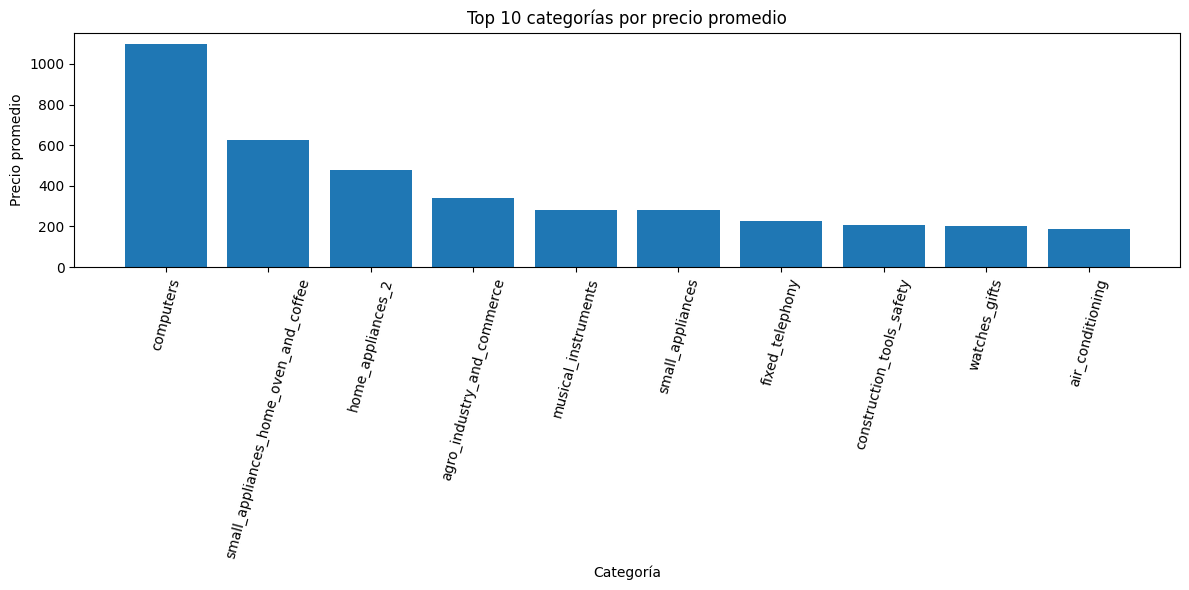

In [14]:
# Ticket promedio por categoría
top_ticket = ticket_promedio.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_ticket["product_category_name_english"], top_ticket["precio_promedio"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías por precio promedio")
plt.ylabel("Precio promedio")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

El análisis del precio promedio por categoría permite identificar diferencias significativas en el valor de los productos comercializados.

La categoría computers presenta el mayor precio promedio, superando los 1.000 unidades monetarias, lo que indica que se trata de productos de alto valor.

De igual forma, categorías como small_appliances_home_oven_and_coffee y home_appliances_2 también presentan precios elevados, lo que sugiere que corresponden a bienes duraderos o de mayor complejidad.

En contraste, otras categorías con alta presencia en el catálogo presentan precios promedio menores, lo que refleja diferentes segmentos de mercado.

Se identifican diferentes estrategias comerciales entre categorías:

Algunas categorías generan ingresos a través de alto volumen de ventas (ej: bed_bath_table)

Otras generan ingresos mediante productos de alto valor unitario (ej: computers)

In [15]:
# Calificación promedio por categoría
reviews_categoria = (
    df_model
    .dropna(subset=["product_category_name_english", "review_score"])
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .reset_index()
    .sort_values(by="review_score", ascending=False)
)

reviews_categoria.head(10)

,product_category_name_english,review_score
11,cds_dvds_musicals,4.642857
29,fashion_childrens_clothes,4.500000
8,books_general_interest,4.446266
22,costruction_tools_tools,4.444444
35,flowers,4.419355
9,books_imported,4.400000
10,books_technical,4.363636
53,luggage_accessories,4.315257
37,food_drink,4.312950
64,small_appliances_home_oven_and_coffee,4.302632


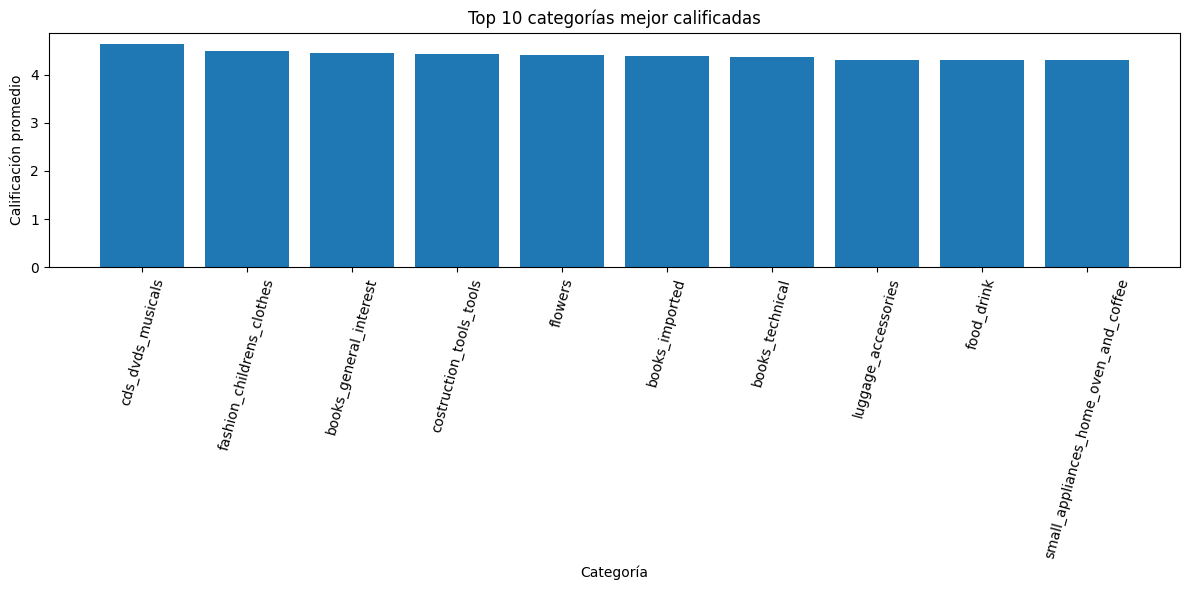

In [16]:
# Gráfica Calificación promedio por categoría
top_reviews = reviews_categoria.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_reviews["product_category_name_english"], top_reviews["review_score"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías mejor calificadas")
plt.ylabel("Calificación promedio")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

Las categorías con mejor satisfacción NO son las que más venden

El análisis de calificaciones promedio por categoría permite identificar los segmentos con mayor nivel de satisfacción por parte de los clientes.

Se observa que categorías como cds_dvds_musicals, fashion_childrens_clothes y books_general_interest presentan las calificaciones más altas, superando valores de 4.4 sobre 5.

Esto sugiere que los productos en estas categorías cumplen adecuadamente con las expectativas del cliente, ya sea por calidad, cumplimiento en la entrega o experiencia general de compra.

Asimismo, categorías como small_appliances_home_oven_and_coffee también destacan, lo cual es relevante dado que anteriormente se identificaron como categorías de alto valor económico.

In [17]:
# cuánto gasta un cliente en una categoría dentro de un pedido
valor_orden_categoria = (
    items_con_categoria.dropna(subset=["product_category_name_english"])
    .groupby(["product_category_name_english", "order_id"])["price"]
    .sum()
    .reset_index(name="valor_orden_categoria")
)

ticket_promedio_categoria = (
    valor_orden_categoria
    .groupby("product_category_name_english")["valor_orden_categoria"]
    .mean()
    .reset_index(name="ticket_promedio")
    .sort_values(by="ticket_promedio", ascending=False)
)

ticket_promedio_categoria["ticket_promedio"] = ticket_promedio_categoria["ticket_promedio"].round(2)
ticket_promedio_categoria.head(20)

,product_category_name_english,ticket_promedio
14,computers,1231.84
64,small_appliances_home_oven_and_coffee,632.61
45,home_appliances_2,484.26
0,agro_industry_and_commerce,398.52
56,musical_instruments,304.93
63,small_appliances,302.95
34,fixed_telephony,274.58
19,construction_tools_safety,242.78
1,air_conditioning,217.49
57,office_furniture,215.95


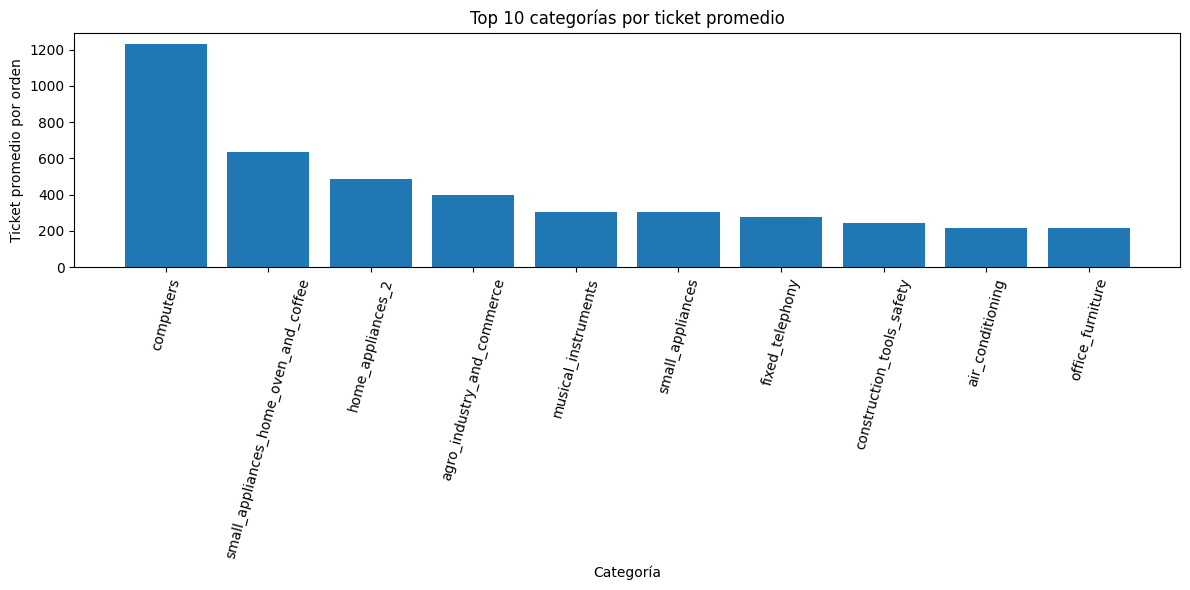

In [18]:
# Gráfica del  gastó de un cliente en una categoría dentro de un pedido
top_ticket = ticket_promedio_categoria.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_ticket["product_category_name_english"], top_ticket["ticket_promedio"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías por ticket promedio")
plt.ylabel("Ticket promedio por orden")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()

Las categorías con mayor ticket promedio representan compras de alto valor, no necesariamente frecuentes

El análisis del ticket promedio por categoría permite evaluar el valor monetario de las compras realizadas por los clientes en cada segmento.

Se observa que la categoría computers presenta el mayor ticket promedio, superando los 1.200, lo que indica que los clientes realizan compras de alto valor en este segmento.

De igual forma, categorías relacionadas con electrodomésticos y equipos especializados presentan valores elevados, lo que sugiere que estas compras suelen involucrar productos de mayor costo o múltiples artículos dentro de una misma orden.

Este análisis permite identificar categorías estratégicas que generan un alto valor por transacción, independientemente del volumen de ventas.

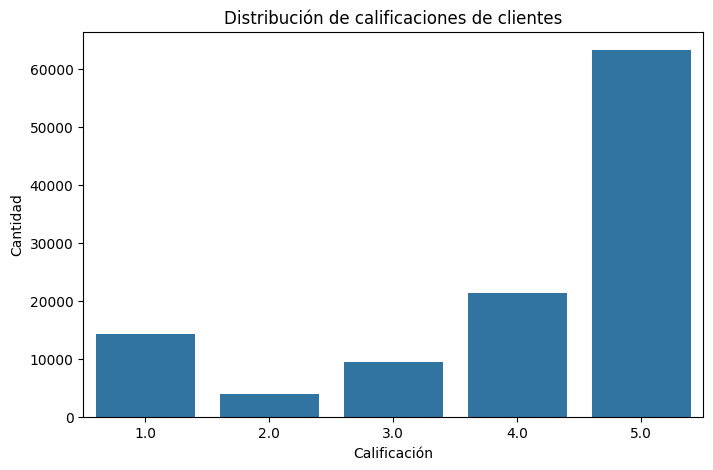

In [19]:
# Distribución de Calificaciones
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="review_score", data=df_model)
plt.title("Distribución de calificaciones de clientes")
plt.xlabel("Calificación")
plt.ylabel("Cantidad")
plt.show()

In [20]:
# ANÁLISIS CUANTITATIVO
(df_model["review_score"]
 .value_counts(normalize=True) * 100)

review_score
5.0    56.477008
4.0    18.992972
1.0    12.674484
3.0     8.398453
2.0     3.457083
Name: proportion, dtype: float64

La distribución de calificaciones muestra una fuerte concentración (58%) en valores altos, especialmente en la calificación de 5 estrellas, la cual representa la mayoría de las evaluaciones realizadas por los clientes.

Las calificaciones de 4 estrellas también presentan una frecuencia significativa (19%), lo que refuerza la percepción de una experiencia de compra positiva.

En contraste, las calificaciones intermedias (2 y 3 estrellas) son menos frecuentes, mientras que las calificaciones de 1 estrella, aunque menores, representan una proporción relevante de experiencias negativas.

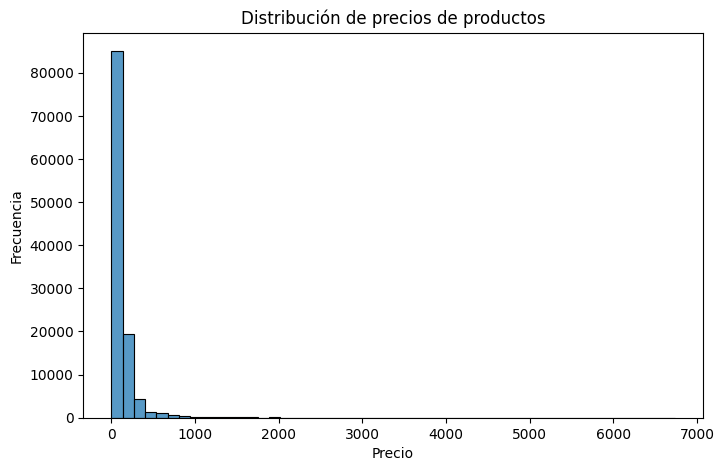

In [21]:
# distribución económica del catálogo
plt.figure(figsize=(8,5))
sns.histplot(items_con_categoria["price"], bins=50)
plt.title("Distribución de precios de productos")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

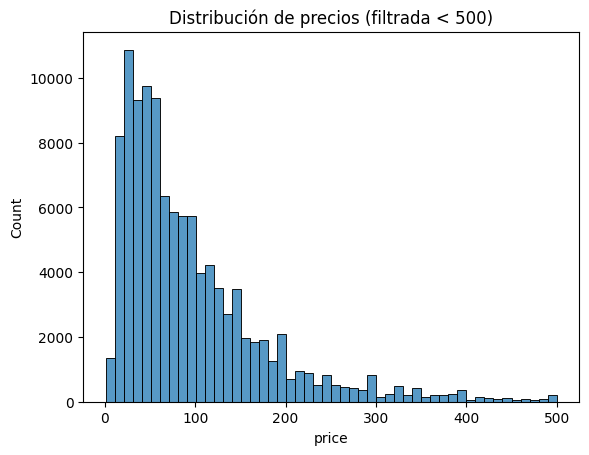

In [22]:
# distribución económica del catálogo
sns.histplot(items_con_categoria[items_con_categoria["price"] < 500]["price"], bins=50)
plt.title("Distribución de precios (filtrada < 500)")
plt.show()

La mayoría de los productos pertenecen a un segmento de bajo costo.

El marketplace está dominado por productos de bajo costo, con una minoría de productos premium

La distribución de precios presenta una fuerte asimetría positiva, donde la mayoría de los productos se concentran en rangos de precios bajos, mientras que un pequeño número de productos alcanza valores significativamente altos.

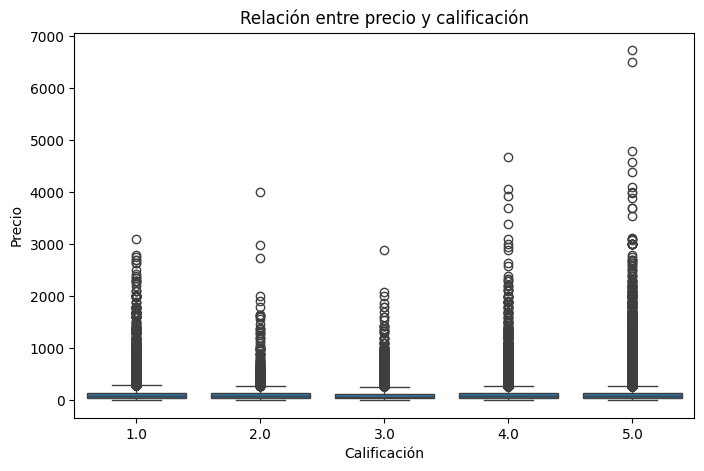

In [23]:
# precio vs satisfacción
plt.figure(figsize=(8,5))
sns.boxplot(
    x="review_score",
    y="price",
    data=df_model.dropna(subset=["review_score", "price"])
)

plt.title("Relación entre precio y calificación")
plt.xlabel("Calificación")
plt.ylabel("Precio")
plt.show()

El precio no determina la satisfacción del cliente

El análisis de la relación entre el precio del producto y la calificación del cliente muestra que no existe una correlación clara entre estas variables.

Las distribuciones de precios son similares en todos los niveles de calificación, lo que indica que productos más costosos no necesariamente reciben mejores valoraciones.

Asimismo, se observa una alta dispersión de precios en todas las categorías de calificación, incluyendo valores atípicos en productos con puntuaciones tanto bajas como altas.

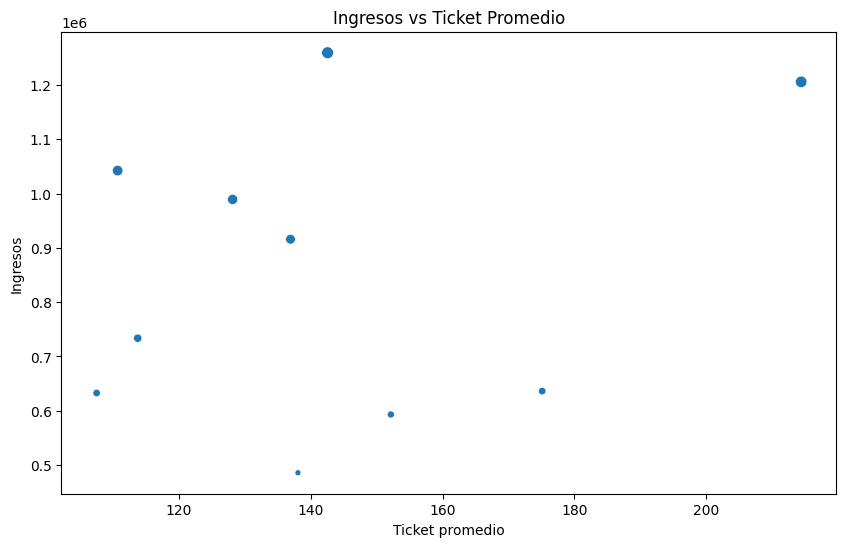

In [24]:
# relación entre el ticket promedio y los ingresos totales
comparacion = ventas_categoria.merge(ticket_promedio_categoria, on="product_category_name_english")

top_comp = comparacion.head(10)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=top_comp,
    x="ticket_promedio",
    y="ingresos_totales",
    size="ingresos_totales",
    legend=False
)

plt.title("Ingresos vs Ticket Promedio")
plt.xlabel("Ticket promedio")
plt.ylabel("Ingresos")
plt.show()

NO existe una relación directa entre estas variables.

Los ingresos dependen de un balance entre volumen y valor, no solo del ticket promedio

Algunas categorías con ticket promedio elevado no necesariamente generan los mayores ingresos, mientras que otras con valores intermedios presentan un alto volumen de ingresos.

Esto sugiere que los ingresos dependen tanto del valor de cada compra como del volumen de ventas, reflejando diferentes dinámicas comerciales dentro del marketplace.

## **Cierre** ##  

En términos de comportamiento de compra, **uno de los hallazgos más relevantes fue que la mayoría de los pedidos contienen un solo producto**, lo que evidencia una baja presencia de compras múltiples dentro de una misma transacción. Este patrón sugiere que actualmente la plataforma no está aprovechando de manera eficiente las oportunidades de venta cruzada, lo cual se alinea directamente con el problema de negocio planteado. La ausencia de mecanismos que incentiven la adquisición de productos complementarios limita el crecimiento del valor promedio por pedido.

Adicionalmente, el análisis por categorías permitió identificar una distribución desigual tanto en volumen de productos como en generación de ingresos. Categorías como bed_bath_table, sports_leisure y furniture_decor concentran una alta cantidad de productos, mientras que otras como health_beauty y watches_gifts destacan por su mayor contribución en ingresos. **Este comportamiento evidencia que el tamaño del catálogo no es el único factor determinante del desempeño económico, sino que intervienen variables como el precio, la demanda y la frecuencia de compra**.

En relación con el valor económico, se identificaron diferencias significativas en el ticket promedio entre categorías. Algunas, como computers y home_appliances, presentan tickets elevados, mientras que otras tienen un enfoque más orientado al volumen con precios más bajos. **Este hallazgo es clave para el desarrollo del proyecto, ya que permite utilizar el ticket promedio como un criterio estratégico para priorizar recomendaciones que contribuyan al incremento del valor de las compras**.

El análisis de precios mostró una distribución altamente sesgada hacia valores bajos, con una concentración significativa de productos económicos y una menor proporción de productos de alto costo. Por su parte, la evaluación de las calificaciones de los clientes evidenció un alto nivel de satisfacción general, con predominio de valoraciones de 4 y 5 estrellas, lo cual indica una experiencia positiva en la mayoría de las transacciones, aunque también se identifican oportunidades de mejora en casos con calificaciones bajas.

Un hallazgo clave fue la ausencia de una relación directa entre el precio de los productos y la calificación otorgada por los clientes, así como entre el ticket promedio y los ingresos totales por categoría. **Esto demuestra que el comportamiento del mercado es multifactorial y que variables como la percepción de valor, la utilidad del producto y la experiencia de compra juegan un papel fundamental en la toma de decisiones del consumidor**.

En conjunto, los resultados del EDA evidencian la existencia de diferentes dinámicas de consumo dentro del marketplace, donde coexisten categorías orientadas al volumen y otras orientadas al valor. **Esta dualidad representa una oportunidad estratégica para diseñar un sistema de recomendación que no solo sugiera productos relevantes, sino que también promueva la complementariedad entre categorías, incentivando la compra de múltiples productos dentro de una misma transacción**.

Finalmente, los hallazgos obtenidos permiten validar el problema de negocio planteado, evidenciando que la plataforma actualmente no cuenta con mecanismos que exploten las relaciones entre categorías ni que utilicen el ticket promedio como criterio de recomendación. En este contexto, el siguiente paso del proyecto se enfocará en el desarrollo de un sistema de recomendación orientado a la venta cruzada, basado en la agrupación de categorías relacionadas y en la priorización de productos que contribuyan al aumento del valor de compra por cliente, en coherencia con el objetivo general definido.




ANALISIS CATEGORIA PET_SHOP

In [25]:
# Número de productos Pet_shop
pet_products = products[products["product_category_name"] == "pet_shop"]
pet_products_count = pet_products["product_id"].nunique()

print("Productos únicos en pet_shop:", pet_products_count)

NameError: name 'products' is not defined

## **ANALISIS SEGMENTADO** ##

Se reconstruyó el dataset final incorporando una nueva segmentación de categorías, lo que permitió mejorar la representatividad de los grupos y reducir significativamente la categoría residual “other”.

## Impacto en el proyecto

La creación de la variable grupo_categoria permite:

-Analizar comportamiento por segmentos

-Detectar oportunidades de cross-selling

-Simplificar el input para modelos de recomendación

-Mejorar la interpretabilidad de resultados

In [26]:
# Distribución de productos por grupo
segmento_productos = (
    df_model.groupby("grupo_categoria")["product_id"]
    .nunique()
    .reset_index(name="cantidad_productos")
    .sort_values(by="cantidad_productos", ascending=False)
)

segmento_productos

,grupo_categoria,cantidad_productos
4,Hogar,9670
8,Recreación,6705
9,Tecnología,3820
2,Cuidado Personal,3324
7,Moda,2523
1,Automotor,1900
11,other,1885
10,Viaje y accesorios,1198
5,Industria y construcción,804
3,Cultura y entretenimiento,751


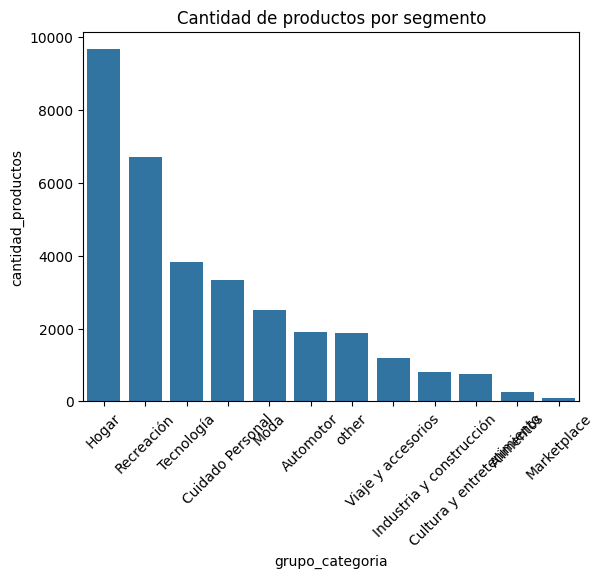

In [27]:
#Grafico de distribución de productos por grupo
sns.barplot(data=segmento_productos, x="grupo_categoria", y="cantidad_productos")
plt.title("Cantidad de productos por segmento")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra la cantidad de productos por grupo_categoria.

Se observa que *Hogar* es el segmento con mayor volumen, seguido por *Recreación* y *Tecnología*, lo que indica una fuerte presencia de estos rubros en el catálogo.

Las categorías como *Cuidado Personal, **Moda* y *Automotor* presentan una distribución intermedia, mientras que otras como *Cultura, **Viaje* e *Industria* tienen menor representación.

En general, la distribución es equilibrada, aunque con predominancia de Hogar, lo que resulta consistente con un entorno de e-commerce y adecuado para el modelado.

In [28]:
# Ingresos totales por grupo
ventas_segmento = (
    df_model.groupby("grupo_categoria")["price"]
    .sum()
    .reset_index(name="ingresos_totales")
    .sort_values(by="ingresos_totales", ascending=False)
)

ventas_segmento

,grupo_categoria,ingresos_totales
4,Hogar,3342481.40
8,Recreación,2735866.18
9,Tecnología,1898587.98
2,Cuidado Personal,1660798.09
7,Moda,1405796.67
11,other,871503.51
1,Automotor,592918.45
10,Viaje y accesorios,371434.20
5,Industria y construcción,360843.22
3,Cultura y entretenimiento,278963.03


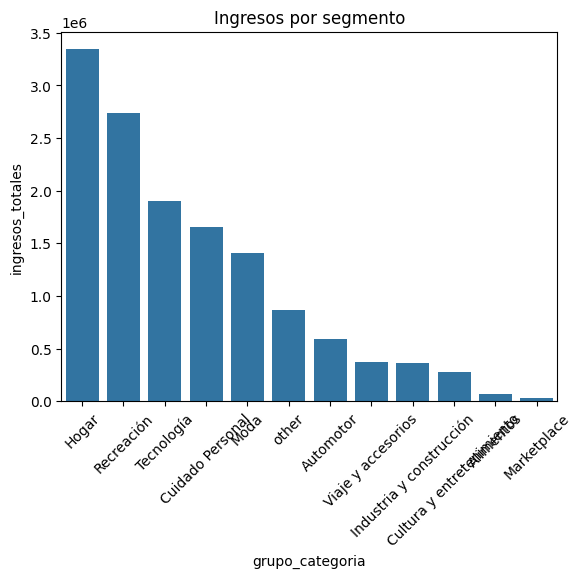

In [32]:
sns.barplot(data=ventas_segmento, x="grupo_categoria", y="ingresos_totales")
plt.title("Ingresos por segmento")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra los ingresos totales por grupo_categoria.

Se observa que *Hogar* lidera ampliamente en generación de ingresos, seguido por *Recreación* y *Tecnología*. 

Esto indica que no solo concentran mayor cantidad de productos, sino también mayor volumen de ventas, convirtiéndose en segmentos clave para el negocio y para el sistema de recomendación.

In [33]:
# Ticket promedio por grupo
ticket_segmento = (
    df_model.groupby("grupo_categoria")["price"]
    .mean()
    .reset_index(name="ticket_promedio")
    .sort_values(by="ticket_promedio", ascending=False)
)

ticket_segmento

,grupo_categoria,ticket_promedio
5,Industria y construcción,171.177998
7,Moda,163.445724
3,Cultura y entretenimiento,162.945695
1,Automotor,139.806284
8,Recreación,126.719138
2,Cuidado Personal,126.306038
11,other,117.137569
9,Tecnología,110.216416
4,Hogar,105.248485
10,Viaje y accesorios,102.861867


El análisis muestra el ticket promedio por grupo_categoria.

Se observa que algunas categorías como *Industria y construcción, **Moda* y *Cultura* presentan tickets más altos, lo que indica compras de mayor valor por producto.

Por otro lado, categorías como *Hogar* y *Tecnología*, aunque generan altos ingresos totales, presentan tickets promedio más bajos, lo que sugiere mayor volumen de ventas.

Este análisis permite diferenciar entre segmentos de alto valor y segmentos de alta rotación.

In [34]:
# Cantidad de ordenes por grupo
ordenes_segmento = (
    df_model.groupby("grupo_categoria")["order_id"]
    .nunique()
    .reset_index(name="cantidad_ordenes")
    .sort_values(by="cantidad_ordenes", ascending=False)
)

ordenes_segmento

,grupo_categoria,cantidad_ordenes
4,Hogar,26026
8,Recreación,19780
9,Tecnología,15311
2,Cuidado Personal,12013
7,Moda,7993
11,other,6289
1,Automotor,3897
10,Viaje y accesorios,3340
5,Industria y construcción,1716
3,Cultura y entretenimiento,1596


El análisis muestra la cantidad de órdenes por grupo_categoria.

Se observa que *Hogar, **Recreación* y *Tecnología* concentran la mayor cantidad de compras, indicando alta demanda en estos segmentos.

Esto refuerza su relevancia para el negocio y los posiciona como categorías clave para el sistema de recomendación.

In [35]:
# Satisfacción (REVIEW SCORE) por grupo
reviews_segmento = (
    df_model
    .dropna(subset=["review_score"])
    .groupby("grupo_categoria")["review_score"]
    .mean()
    .reset_index(name="rating_promedio")
    .sort_values(by="rating_promedio", ascending=False)
)

reviews_segmento

,grupo_categoria,rating_promedio
3,Cultura y entretenimiento,4.283863
10,Viaje y accesorios,4.231541
0,Alimentos,4.182373
2,Cuidado Personal,4.144564
8,Recreación,4.116769
1,Automotor,4.063364
7,Moda,4.049689
5,Industria y construcción,4.036877
6,Marketplace,4.019417
11,other,3.987392


Este análisis evalúa la percepción de los usuarios mediante el puntaje promedio de reviews.

Es clave para detectar segmentos con problemas de calidad o experiencia, y también para potenciar recomendaciones en aquellos con mayor nivel de satisfacción.

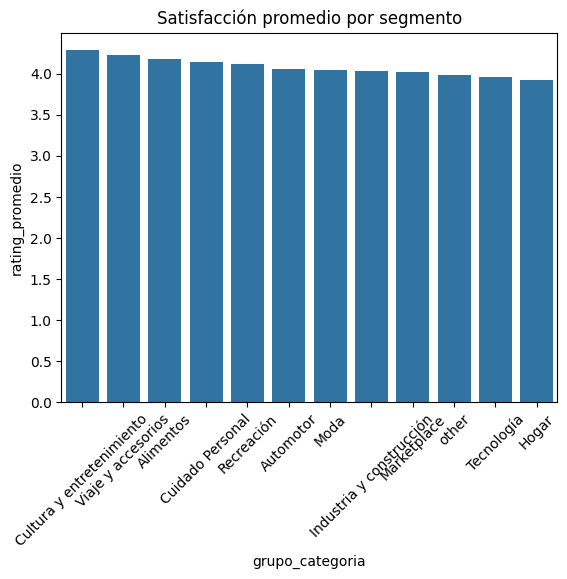

In [36]:
sns.barplot(data=reviews_segmento, x="grupo_categoria", y="rating_promedio")
plt.title("Satisfacción promedio por segmento")
plt.xticks(rotation=45)
plt.show()

El análisis muestra el puntaje promedio (review_score) por grupo_categoria.

Se observa una valoración alta y bastante homogénea entre segmentos, aunque *other* presenta el menor rating.

Esto permite identificar oportunidades de mejora en la experiencia del cliente y priorizar segmentos con menor satisfacción.

In [37]:
# Cantidad de productos por orden por grupo
productos_por_orden_segmento = (
    df_model.groupby(["grupo_categoria", "order_id"])["order_item_id"]
    .count()
    .reset_index(name="productos_por_orden")
)

productos_por_orden_segmento.groupby("grupo_categoria")["productos_por_orden"].mean()

grupo_categoria
Alimentos                    1.199179
Automotor                    1.088273
Cuidado Personal             1.094564
Cultura y entretenimiento    1.072682
Hogar                        1.220241
Industria y construcción     1.228438
Marketplace                  1.110714
Moda                         1.076067
Recreación                   1.091507
Tecnología                   1.125073
Viaje y accesorios           1.081138
other                        1.183018
Name: productos_por_orden, dtype: float64

Este análisis permite entender el comportamiento de compra de los usuarios en cada segmento.

Es especialmente relevante para sistemas de recomendación, ya que segmentos con mayor cantidad de productos por orden pueden indicar oportunidades de cross-selling.

El análisis muestra la cantidad promedio de productos por orden en cada grupo_categoria.

Se observa un comportamiento bastante homogéneo entre segmentos, con leves variaciones en categorías como *Hogar* e *Industria*.

Esto indica que, en general, los clientes compran una cantidad similar de productos por compra, independientemente del segmento.

In [38]:
# Análisis de cross-selling entre grupos
cross = df_model.groupby("order_id")["grupo_categoria"].unique()

from itertools import combinations
from collections import Counter

pares = []

for categorias in cross:
    if len(categorias) > 1:
        pares.extend(combinations(categorias, 2))

conteo_pares = Counter(pares)

cross_selling = pd.DataFrame(conteo_pares.items(), columns=["pares", "frecuencia"])
cross_selling.sort_values(by="frecuencia", ascending=False).head(10)

,pares,frecuencia
19,"(other, Hogar)",64
11,"(Hogar, other)",60
26,"(Hogar, Recreación)",38
10,"(Recreación, Hogar)",37
7,"(Hogar, Industria y construcción)",16
36,"(Recreación, other)",14
6,"(Hogar, Cuidado Personal)",13
1,"(Cuidado Personal, Recreación)",13
13,"(Recreación, Cuidado Personal)",12
9,"(Recreación, Tecnología)",12


Este análisis identifica qué segmentos suelen comprarse juntos dentro de una misma orden.

Es fundamental para el desarrollo del sistema de recomendación, ya que permite detectar patrones de cross-selling y sugerir productos complementarios de manera más efectiva.

El análisis identifica combinaciones frecuentes de categorías compradas en una misma orden.

Se observa que pares como *Hogar - Recreación* y *Hogar - Salud* son los más frecuentes.

Esto permite detectar oportunidades de *cross-selling* y mejorar el sistema de recomendación sugiriendo productos complementarios.

In [39]:
# Resumen 
resumen_segmento = (
    df_model.groupby("grupo_categoria")
    .agg({
        "price": ["sum", "mean"],
        "order_id": "nunique",
        "review_score": "mean"
    })
)

resumen_segmento.columns = [
    "ingresos_totales",
    "ticket_promedio",
    "cantidad_ordenes",
    "rating_promedio"
]

resumen_segmento = resumen_segmento.reset_index()

resumen_segmento

,grupo_categoria,ingresos_totales,ticket_promedio,cantidad_ordenes,rating_promedio
0,Alimentos,67040.58,57.397757,974,4.182373
1,Automotor,592918.45,139.806284,3897,4.063364
2,Cuidado Personal,1660798.09,126.306038,12013,4.144564
3,Cultura y entretenimiento,278963.03,162.945695,1596,4.283863
4,Hogar,3342481.40,105.248485,26026,3.927091
5,Industria y construcción,360843.22,171.177998,1716,4.036877
6,Marketplace,28378.47,91.249100,280,4.019417
7,Moda,1405796.67,163.445724,7993,4.049689
8,Recreación,2735866.18,126.719138,19780,4.116769
9,Tecnología,1898587.98,110.216416,15311,3.954344


Esta tabla integra las principales métricas analizadas: ingresos, ticket promedio, cantidad de órdenes y nivel de satisfacción.

Permite tener una visión consolidada del desempeño de cada segmento y facilita la toma de decisiones estratégicas para el sistema de recomendación.

Se observa que segmentos como *Hogar* y *Recreación* destacan en volumen de ventas, mientras que otros como *Industria* presentan tickets promedio más altos.

Este análisis permite identificar segmentos clave tanto por volumen como por valor, fundamentales para el modelado y las estrategias de recomendación.

## Conclusión
El análisis exploratorio permitió identificar patrones clave en el comportamiento de compra. Los segmentos como *Hogar, **Recreación* y *Tecnología* concentran la mayor demanda, mientras que otros presentan mayor ticket promedio.

Se detectaron oportunidades de *cross-selling* entre categorías y una alta homogeneidad en la satisfacción de los usuarios, con algunas excepciones a mejorar.

La nueva segmentación permitió reducir la categoría other, logrando una mejor representación del negocio y dejando una base sólida para el modelado del sistema de recomendación.
